![Py4Eng](../logo.png)

# Imbalanced data
## Yoav Ram

In this session we will understand:
- why a model can report **99.7% accuracy** and still find **2 of 183** hands of a class we care about
- the difference between **plain accuracy** and **macro recall**, and which classes we are entitled to score at all
- how to compute a **ceiling for the task from the data alone**, before any model exists
- what **resampling the minibatch** changes, and what it does not
- why *"the model cannot learn this class"* and *"the model has not learned it yet"* look identical at a fixed training budget
- why **class-weighted loss** and **logit adjustment** are not drop-in replacements for resampling
- why a diagnostic needs a **control**, and the right column, before it is evidence — a probe score, a weight norm

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import time
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             recall_score, roc_auc_score)

import jax
import jax.numpy as jnp
import optax
import keras
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 8765
sns.set(style='white', context='talk')
red, blue, green = sns.color_palette('Set1', 3)

Keras: 3.15.1 backend: jax gpu


# The data

We use the [poker hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) from the UCI repository.
Each row is a five-card hand: five (suit, rank) pairs, and a class in 0-9 naming the hand — *nothing*, *one pair*, *two pairs*, and so on up to *royal flush*.

Two things make it a good dataset for this session, and both are unusual.

1. **The class is a deterministic, noiseless function of the input.** A hand *is* a flush or it is not; there is no label noise, no ambiguity, and no irreducible error. A perfect classifier exists. We will lean on that at the end, because it is exactly what makes some of what we measure here *not* generalize to real data.
2. **The classes are wildly imbalanced**, and not by an accident of collection — by the rules of the game. Half of all hands are *nothing*, and the whole 1,025,010-hand file contains eight royal flushes.

UCI ships the data as two files, a 25,010-hand "training" file and a 1,000,000-hand "testing" file. We concatenate them and make our own split, so those names carry no meaning below.

In [2]:
DATA = Path('../data')
POKER_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/'
FILES = ['poker-hand-training-true.data', 'poker-hand-testing.data']

for name in FILES:                      # or: python download_data.py poker
    if not (DATA / name).exists():
        print('downloading', name)
        urllib.request.urlretrieve(POKER_URL + name, DATA / name)

raw = np.concatenate([pd.read_csv(DATA / name, header=None).to_numpy(np.int32) for name in FILES])
print('{:,} hands'.format(len(raw)))
raw[:3]

1,025,010 hands


array([[ 1, 10,  1, 11,  1, 13,  1, 12,  1,  1,  9],
       [ 2, 11,  2, 13,  2, 10,  2, 12,  2,  1,  9],
       [ 3, 12,  3, 11,  3, 13,  3, 10,  3,  1,  9]], dtype=int32)

Columns are `S1, C1, S2, C2, ..., S5, C5, class`: the suit and rank of each card, then the label.
Suits are 1-4 and ranks 1-13 with 1 = Ace; we shift both to 0-based, because they are about to become indices into an embedding table.

We keep suits and ranks as two separate `(n, 5)` integer arrays rather than one flat vector of ten numbers. The model below reads them separately, and so does the analysis in the middle of the notebook.

In [3]:
suits = raw[:, 0:10:2] - 1     # 0-3
ranks = raw[:, 1:10:2] - 1     # 0-12, with 0 = Ace
labels = raw[:, 10]

CLASSES = ['Nothing', 'One pair', 'Two pairs', 'Three of a kind', 'Straight',
           'Flush', 'Full house', 'Four of a kind', 'Straight flush', 'Royal flush']
print(suits[0], ranks[0], CLASSES[labels[0]])

[0 0 0 0 0] [ 9 10 12 11  0] Royal flush


An 80/10/10 split into training, validation and test sets. We only use the first two here; the test set is held back so that the exercises at the end have somewhere honest to report.

The split is a uniformly random permutation. Nothing in this dataset is ordered in time and every hand is independent, so there is no structure to respect — and we deliberately do *not* stratify by class, because the class frequencies are the phenomenon we are studying.

In [4]:
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(raw))
ntrain, nval = int(0.8 * len(raw)), int(0.1 * len(raw))
itrain, ival = perm[:ntrain], perm[ntrain:ntrain + nval]

train_suits, train_ranks, train_y = suits[itrain], ranks[itrain], labels[itrain]
val_suits, val_ranks, val_y = suits[ival], ranks[ival], labels[ival]
print('{:,} training hands, {:,} validation hands'.format(len(train_y), len(val_y)))

820,008 training hands, 102,501 validation hands


Here is the whole problem, in one table.

In [5]:
train_counts = np.bincount(train_y, minlength=10)
val_counts = np.bincount(val_y, minlength=10)

counts = pd.DataFrame({'train': train_counts, 'validation': val_counts}, index=CLASSES)
counts['% of train'] = 100 * counts.train / counts.train.sum()
counts.style.format({'train': '{:,}', 'validation': '{:,}', '% of train': '{:.3f}'})

,train,validation,% of train
Nothing,"410,686","51,472",50.083
One pair,"346,757","43,276",42.287
Two pairs,"38,997","4,813",4.756
Three of a kind,"17,339","2,176",2.114
Straight,"3,184",409,0.388
Flush,"1,661",183,0.203
Full house,"1,181",145,0.144
Four of a kind,188,25,0.023
Straight flush,10,1,0.001
Royal flush,5,1,0.001


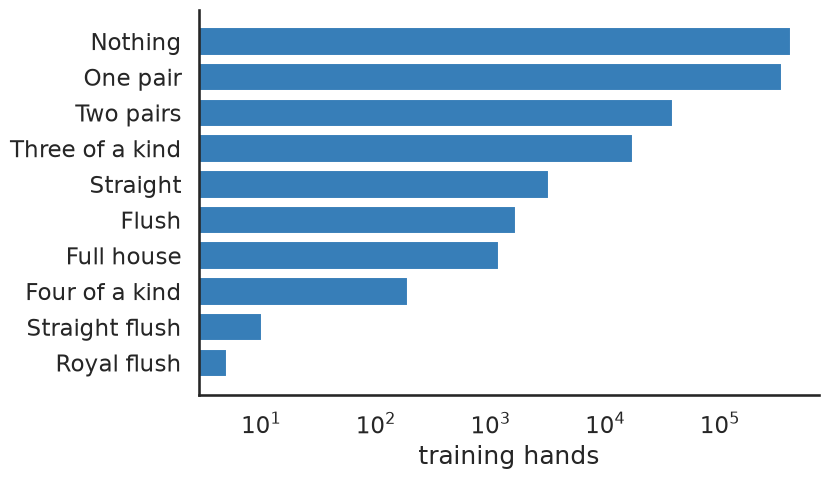

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.arange(10), train_counts, color=blue)
ax.set(yticks=np.arange(10), yticklabels=CLASSES, xscale='log', xlabel='training hands')
ax.invert_yaxis()
sns.despine()

Five orders of magnitude, on a log axis, from 410,000 down to a handful.

## Two classes we are not allowed to score

**Straight flush** and **royal flush** have 10 and 5 training hands, and 1 and 1 in validation.

There is nothing to be done about this, and pretending otherwise is the first mistake available to us. A macro average over all ten classes would give each of those two the same weight as *nothing* — so a single lucky straight flush would move the summary by 10 points, and the number would be reporting the outcome of one coin flip. Five training examples is also not a sample from which anything can be learned.

So we state it once, here, and then **report macro averages over the 8 classes with at least 20 validation hands**. The other two stay in the data — the model still has to do *something* with them, and they still cost us if it gets them wrong on a hand that matters — but they are not scored.

One detail that matters more than it looks:

In [7]:
REPORTED = [c for c in range(10) if val_counts[c] >= 20]
REPORTED_NAMES = [CLASSES[c] for c in REPORTED]
print('scored classes:', REPORTED_NAMES)

def scores(y_pred, y_true=val_y):
    """Plain accuracy and macro recall over the 8 scored classes."""
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        macro_recall=recall_score(y_true, y_pred, labels=REPORTED, average='macro', zero_division=0),
    )

scored classes: ['Nothing', 'One pair', 'Two pairs', 'Three of a kind', 'Straight', 'Flush', 'Full house', 'Four of a kind']


`labels=REPORTED` is not decoration. By default scikit-learn's macro average is taken over every class that appears in `y_true` *or* in `y_pred`, so a single stray royal-flush prediction would quietly add a tenth term to the average and change the denominator underneath us. Passing `labels=` explicitly fixes what we are averaging over, and keeps the number comparable between models.

# A flattened feed forward network

The model is the [feed forward network](FFN.ipynb) from the previous session, with one addition at the input.

Suits and ranks are **categorical**. Feeding the integer 12 for a King into a linear layer would tell the model that a King is twelve times an Ace and one more than a Queen, which is false and would have to be unlearned. Instead each suit and each rank gets its own learned vector — an **embedding table**, a lookup of a $(4, 8)$ and a $(13, 16)$ matrix:

$$ x = \Big[\; e^{suit}_{s_1} \,,\, e^{rank}_{r_1} \,,\, \ldots \,,\, e^{suit}_{s_5} \,,\, e^{rank}_{r_5} \;\Big] \in \mathbb{R}^{120} $$

Then we flatten those five cards into one vector and put a single hidden layer and a readout layer on top — an ordinary FFN.

Flattening is worth a moment. A hand is a *set*: the same five cards in a different order is the same hand, and our model has no idea. Card 1 and card 4 go through completely separate weights, so the network has to learn each rule five times over, once per position. Architectures that know a hand is a set (a set transformer, say) fix this. We are using the FFN on purpose: this session is about the data, not the architecture, and we want a model whose failure we can attribute to the data.

In [8]:
NSUITS, NRANKS, NCARDS, NCLASSES = 4, 13, 5, 10
DSUIT, DRANK, NHIDDEN = 8, 16, 150

def init_params(key):
    ksuit, krank, k1, k2 = jax.random.split(key, 4)
    glorot = jax.nn.initializers.glorot_uniform()
    return dict(
        suit=jax.random.normal(ksuit, (NSUITS, DSUIT)) * 0.02,
        rank=jax.random.normal(krank, (NRANKS, DRANK)) * 0.02,
        W1=glorot(k1, (NCARDS * (DSUIT + DRANK), NHIDDEN)), b1=jnp.zeros(NHIDDEN),
        W2=glorot(k2, (NHIDDEN, NCLASSES)), b2=jnp.zeros(NCLASSES),
    )

def features(params, s, r):
    """The hidden layer: what the readout layer gets to see."""
    x = jnp.concatenate([params['suit'][s], params['rank'][r]], axis=-1)
    x = x.reshape(x.shape[0], -1)                      # flatten the five cards
    return jax.nn.relu(x @ params['W1'] + params['b1'])

def logits(params, s, r):
    return features(params, s, r) @ params['W2'] + params['b2']

def loss(params, s, r, y):
    return optax.softmax_cross_entropy_with_integer_labels(logits(params, s, r), y).mean()

print('{:,} parameters'.format(sum(x.size for x in jax.tree.leaves(init_params(jax.random.key(0))))))

19,900 parameters


Twenty thousand parameters, for 820,000 training hands. Whatever goes wrong below, it will not be because the model memorised the training set.

## The only thing we will change

Every run below uses the same architecture, the same initialisation, the same optimizer (`adamw`, learning rate $10^{-3}$, weight decay $10^{-4}$), the same batch size and the same number of steps. **The only difference between runs is which hands go into the minibatch.**

We draw a minibatch in two stages: pick a *class*, then pick a hand of that class. The probability of picking class $c$ is

$$ w_c \propto n_c^\alpha $$

where $n_c$ is how many training hands of that class we have. Three values of $\alpha$ matter:

| $\alpha$ | name | what it does |
|---|---|---|
| 1 | **natural** | $w_c \propto n_c$: identical to sampling uniformly from the training set |
| 0 | **balanced** | every class equally likely, however rare |
| 0.5 | **√-balanced** | a compromise; rare classes are boosted, but not all the way |

To keep the sampler `jit`-friendly we build a **padded index pool**: a $(10, L)$ array where row $c$ holds the indices of class $c$, cycled to fill the width $L$ of the largest class. Then a batch is two `randint`-style draws and one fancy-index — all fixed-shape, so it compiles once and never re-traces.

One warning about the numbers below. Fixing the seed does *not* make these runs bit-reproducible on a GPU: the order of floating-point reductions is not guaranteed, and 50,000 steps amplify the difference. Two runs of the same code with the same seed land a point or two apart on macro recall. Every claim we make below is therefore checked across seeds, and the ones that rest on a single run are labelled as such.

In [9]:
class_idx = [np.where(train_y == c)[0] for c in range(NCLASSES)]
L = max(len(ix) for ix in class_idx)
pool = jnp.asarray(np.stack([ix[np.arange(L) % len(ix)] for ix in class_idx]))

train_suits_d, train_ranks_d, train_y_d = map(jnp.asarray, (train_suits, train_ranks, train_y))
print('index pool', pool.shape)

index pool (10, 410686)


In [10]:
BATCH, STEPS = 256, 50_000

def train(alpha, seed=0, steps=STEPS, loss_fn=loss):
    w = train_counts.astype(float) ** alpha
    w = jnp.asarray(w / w.sum())
    opt = optax.adamw(1e-3, weight_decay=1e-4)
    params = init_params(jax.random.key(seed))
    state = opt.init(params)

    @jax.jit
    def step(params, state, key):
        kclass, khand = jax.random.split(key)
        c = jax.random.choice(kclass, NCLASSES, (BATCH,), p=w)
        j = jax.random.randint(khand, (BATCH,), 0, L)
        idx = pool[c, j]
        grads = jax.grad(loss_fn)(params, train_suits_d[idx], train_ranks_d[idx], train_y_d[idx])
        updates, state = opt.update(grads, state, params)
        return optax.apply_updates(params, updates), state

    key = jax.random.key(seed + 1000)
    for _ in range(steps):
        key, subkey = jax.random.split(key)
        params, state = step(params, state, subkey)
    return jax.block_until_ready(params)

Prediction is one `argmax` over the logits, in chunks so that a million hands do not have to sit on the accelerator at once.

In [11]:
@jax.jit
def predict_batch(params, s, r):
    return logits(params, s, r).argmax(axis=-1)

def predict(params, s=val_suits, r=val_ranks, chunk=100_000):
    return np.concatenate([np.asarray(predict_batch(params, jnp.asarray(s[i:i + chunk]), jnp.asarray(r[i:i + chunk])))
                           for i in range(0, len(s), chunk)])

Now we train the three regimes. Each takes about 30 seconds on a GPU and a few minutes on a CPU, so the training cell is commented out and we load saved parameters instead. Those checkpoints are **committed to the repository** (`../data/poker_ffn_*.p`, about 350 KB in total, along with the probe heads and the budget curve further down), so nothing in this notebook needs to be trained before it will run. Uncomment the cell to reproduce them — and see the warning above about what "reproduce" means on a GPU.

In [12]:
REGIMES = {'natural': 1.0, 'balanced': 0.0, 'sqrt': 0.5}

# for name, alpha in REGIMES.items():
#     t0 = time.time()
#     params = train(alpha)
#     print('{:9s} trained in {:.0f}s'.format(name, time.time() - t0))
#     with open(DATA / 'poker_ffn_{}.p'.format(name), 'wb') as f:
#         pickle.dump(jax.tree.map(np.asarray, params), f)

def load(name):
    with open(DATA / 'poker_ffn_{}.p'.format(name), 'rb') as f:
        return jax.tree.map(jnp.asarray, pickle.load(f))

models = {name: load(name) for name in REGIMES}
pred = {name: predict(params) for name, params in models.items()}

# The number that hides everything

Start where anyone would start: train on the data as it comes, and ask for the accuracy.

In [13]:
print('accuracy: {:.2%}'.format(scores(pred['natural'])['accuracy']))

accuracy: 99.73%


That is a very good number. It is also almost meaningless, and the quickest way to see why is to compare it to a model that does not exist.

**The majority-class baseline** answers *Nothing* to every hand, always, without looking at the cards.

In [14]:
majority = np.zeros_like(val_y)
print('majority baseline: {accuracy:.2%} accuracy, {macro_recall:.1%} macro recall'.format(**scores(majority)))

majority baseline: 50.22% accuracy, 12.5% macro recall


A constant answer scores 50%. So the accuracy scale we are working on does not run from 0 to 100 — it effectively runs from 50 to 100, and half of it is free. Worse, most of the remaining half is *one pair*, which is another 42% of the data. Two classes out of ten account for 92% of all hands, so a model that handles those two and nothing else already reports 92%.

Accuracy is an average over *hands*. When hands are distributed like this, it is a report on the common classes with the rare ones rounded away.

**Macro recall** is the alternative: compute recall separately within each class, then average the classes, giving each equal weight regardless of size. The majority baseline scores 12.5% — one class out of eight — which is what a useless model should look like.

Let us look at the per-class numbers.

In [15]:
def report(y_pred):
    print(classification_report(val_y, y_pred, labels=REPORTED, target_names=REPORTED_NAMES,
                                digits=3, zero_division=0))
    print('plain accuracy {accuracy:.4f}   macro recall {macro_recall:.4f}'.format(**scores(y_pred)))

report(pred['natural'])

                 precision    recall  f1-score   support

        Nothing      0.997     0.999     0.998     51472
       One pair      1.000     1.000     1.000     43276
      Two pairs      0.999     0.999     0.999      4813
Three of a kind      0.998     0.994     0.996      2176
       Straight      0.993     1.000     0.996       409
          Flush      0.030     0.011     0.016       183
     Full house      0.889     0.993     0.938       145
 Four of a kind      0.947     0.720     0.818        25

      micro avg      0.997     0.997     0.997    102499
      macro avg      0.857     0.839     0.845    102499
   weighted avg      0.996     0.997     0.997    102499

plain accuracy 0.9973   macro recall 0.8395


There it is.

**Flush: 1.1% recall.** Two hands out of 183. The model has essentially never named a flush, and the 99.7% accuracy did not so much as flinch, because 183 hands out of 102,499 cannot move its third decimal place.

Notice what is *not* failing. *Full house* has 1,181 training hands — **fewer than flush's 1,661** — and the model gets 144 of its 145 validation hands right. *Straight* has 3,184 and is perfect. So being rare is not, by itself, what breaks a class here.

*Four of a kind* is at 72%, which is 18 hands out of 25. We will come back to how little weight a 25-hand class can carry.

The confusion matrix says where the flushes went.

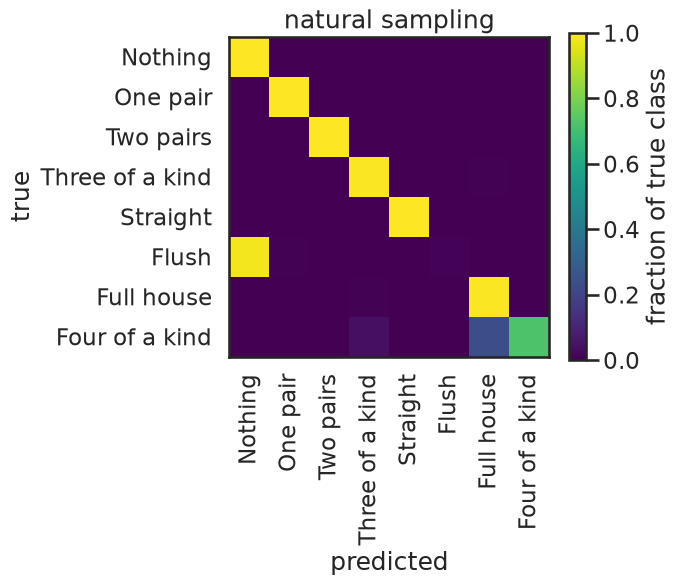

In [16]:
def plot_confusion(y_pred, ax, title, ylabels=True):
    conf = confusion_matrix(val_y, y_pred, labels=REPORTED, normalize='true')
    im = ax.imshow(conf, cmap='viridis', vmin=0, vmax=1)
    ax.set(xticks=range(len(REPORTED)), yticks=range(len(REPORTED)), title=title,
           xlabel='predicted', ylabel='true' if ylabels else '')
    ax.set_xticklabels(REPORTED_NAMES, rotation=90)
    ax.set_yticklabels(REPORTED_NAMES if ylabels else [])
    return im

fig, ax = plt.subplots(figsize=(7, 6))
im = plot_confusion(pred['natural'], ax, 'natural sampling')
fig.colorbar(im, ax=ax, label='fraction of true class')
fig.tight_layout()

The flush row is almost entirely in the *nothing* column. That is not a random error: a flush *is* five cards of no particular rank pattern, differing from *nothing* only in that all five suits agree. The model has learned to answer the rank question and to ignore the suits — and 99.7% of the time, that is right.

# Before blaming the model: what does the task require?

Here is the most transferable idea in this session, and it costs three lines of code and no training.

The label of a hand is decided by two things: the pattern of **ranks** (are there pairs? a run?) and whether the **suits** all agree. Suppose a model could read the ranks perfectly but was blind to suits. How well could it possibly do?

We can answer that from the data. Summarise each hand by its **rank signature** — the multiset pattern of rank counts, plus whether the five ranks form a run — and group the training hands by it.

In [17]:
def rank_signature(hand_ranks):
    pattern = tuple(sorted(Counter(hand_ranks).values(), reverse=True))
    s = sorted(hand_ranks)
    run = bool(len(set(s)) == 5 and (s[4] - s[0] == 4 or s == [0, 9, 10, 11, 12]))  # A-10-J-Q-K
    return pattern, run

groups = {}
for r, y in zip(train_ranks.tolist(), train_y.tolist()):
    groups.setdefault(rank_signature(r), Counter())[y] += 1

for sig, counter in sorted(groups.items(), key=lambda kv: -sum(kv[1].values())):
    print(sig, {CLASSES[c]: n for c, n in counter.most_common()})

((1, 1, 1, 1, 1), False) {'Nothing': 410686, 'Flush': 1661}
((2, 1, 1, 1), False) {'One pair': 346757}
((2, 2, 1), False) {'Two pairs': 38997}
((3, 1, 1), False) {'Three of a kind': 17339}
((1, 1, 1, 1, 1), True) {'Straight': 3184, 'Straight flush': 10, 'Royal flush': 5}
((3, 2), False) {'Full house': 1181}
((4, 1), False) {'Four of a kind': 188}


Seven groups, and five of them are **pure**: a hand with rank pattern $(2,1,1,1)$ is one pair, always, and no suit can change that. Only two groups are ambiguous, and both are ambiguous in the same way:

```
(1,1,1,1,1) not a run  ->  Nothing  or  Flush
(1,1,1,1,1) a run      ->  Straight or  Straight flush / Royal flush
```

Exactly the hands where the answer depends on the suits.

So the **best possible suit-blind model** answers each group with its most common class. This is a genuine ceiling: no model that ignores suits, however large, can beat it.

In [18]:
oracle_of = {sig: counter.most_common(1)[0][0] for sig, counter in groups.items()}
oracle = np.array([oracle_of[rank_signature(r)] for r in val_ranks.tolist()])

print('suit-blind ceiling: {accuracy:.2%} accuracy, {macro_recall:.1%} macro recall'.format(**scores(oracle)))
print('  flush recall: {:.1%}'.format(recall_score(val_y, oracle, labels=[5], average='macro', zero_division=0)))

suit-blind ceiling: 99.82% accuracy, 87.5% macro recall


  flush recall: 0.0%


This one table reframes everything.

- **99.82% accuracy without ever looking at a suit.** Reading the suits is worth 0.18 percentage points of accuracy. On the metric we started with, the entire suit half of the input is worth a rounding error — and each step of gradient descent divides its attention in the same proportion.
- **87.5% macro recall**, which is exactly $7/8$: seven scored classes perfect, flush at zero. A suit-blind model *cannot* get a single flush right, because every flush lives in a group where *nothing* outnumbers it 250 to 1.

Now compare our model to its own ceiling.

In [19]:
summary = pd.DataFrame(
    {'suit-blind ceiling': scores(oracle), 'natural sampling': scores(pred['natural'])}
).T
summary.style.format('{:.5f}')

,accuracy,macro_recall
suit-blind ceiling,0.99820,0.87500
natural sampling,0.99726,0.83946


Our trained network scores **83.9% macro against the ceiling's 87.5%** — lower than a model that cannot see suits at all, and the same is true at two other seeds (83.7%, 85.3%).

Before making anything of that summary, look at where the difference is, because it is not where the story wants it to be. Almost the entire gap is **four of a kind**: 18 of 25 hands against the ceiling's 25 of 25. A 25-hand class moves four points of its own recall, and half a point of the macro, *per hand*. That is a difference we cannot defend, and we will not build on it.

What we can defend is the comparison class by class, and there the picture is stark:

| | suit-blind ceiling | our network |
|---|---:|---:|
| flush recall | 0% (it is blind to suits) | 1.1% |
| everything else | perfect by construction | 99.3-100%, except four of a kind |

**A model that cannot see suits and a model that can are scoring the same on flushes.** That is the finding. The suits are in the input, the network has 20,000 parameters with which to use them, and the flush column of the output looks exactly as if they had been deleted.

The ceiling also tells us why. Cross-entropy averaged over hands drawn at their natural frequencies gives the whole flush class about **0.2% of every step's gradient**.

Be careful about how strongly to put that. It is *not* that the objective does not care about flushes: the labels are noiseless, so this objective's own optimum is a perfect classifier, flushes included — and later in this notebook we will watch it get there. It is that flushes are barely rewarded *per step*, which buys a very slow climb. The model is not malfunctioning, and it is not aiming at the wrong target. It is succeeding slowly at the objective we gave it, which counts hands.

# Changing the sampler

We gave the model an objective in which flushes barely count. So change it — not by touching the loss, the architecture, the optimizer or the budget, but by changing which hands go into the minibatch.

In [20]:
table = pd.DataFrame({name: scores(p) for name, p in pred.items()}).T
table.loc['suit-blind ceiling'] = scores(oracle)
table.loc['majority baseline'] = scores(majority)
table.style.format('{:.5f}')

,accuracy,macro_recall
natural,0.99726,0.83946
balanced,0.99991,0.97827
sqrt,0.99998,1.00000
suit-blind ceiling,0.99820,0.87500
majority baseline,0.50216,0.12500


In [21]:
recalls = pd.DataFrame(
    {name: recall_score(val_y, p, labels=REPORTED, average=None, zero_division=0) for name, p in pred.items()},
    index=REPORTED_NAMES)
recalls.insert(0, 'val hands', val_counts[REPORTED])
recalls.style.format({'val hands': '{:,}', **{name: '{:.3f}' for name in pred}})

,val hands,natural,balanced,sqrt
Nothing,"51,472",0.999,1.000,1.000
One pair,"43,276",1.000,1.000,1.000
Two pairs,"4,813",0.999,1.000,1.000
Three of a kind,"2,176",0.994,1.000,1.000
Straight,409,1.000,1.000,1.000
Flush,183,0.011,1.000,1.000
Full house,145,0.993,0.986,1.000
Four of a kind,25,0.720,0.840,1.000


Both resampled regimes recover the flush completely — **100% recall, from 1.1%** — and macro recall goes from 83.9% to 97.8% (balanced) and 100.0% (√-balanced). The √-balanced run here happens to get every one of the eight scored classes exactly right; across three seeds it lands between 98.6% and 100%, so read that 1.0000 as "as good as this task allows", not as a number to reproduce.

And — this is the part worth being suspicious about — **plain accuracy went up too**, from 99.73% to 99.99%. The usual story about resampling says the opposite: that rare-class recall is bought with common-class accuracy. Let us check the common classes directly, with precision as well as recall.

In [22]:
report(pred['sqrt'])

                 precision    recall  f1-score   support

        Nothing      1.000     1.000     1.000     51472
       One pair      1.000     1.000     1.000     43276
      Two pairs      1.000     1.000     1.000      4813
Three of a kind      1.000     1.000     1.000      2176
       Straight      0.995     1.000     0.998       409
          Flush      1.000     1.000     1.000       183
     Full house      1.000     1.000     1.000       145
 Four of a kind      1.000     1.000     1.000        25

      micro avg      1.000     1.000     1.000    102499
      macro avg      0.999     1.000     1.000    102499
   weighted avg      1.000     1.000     1.000    102499

plain accuracy 1.0000   macro recall 1.0000


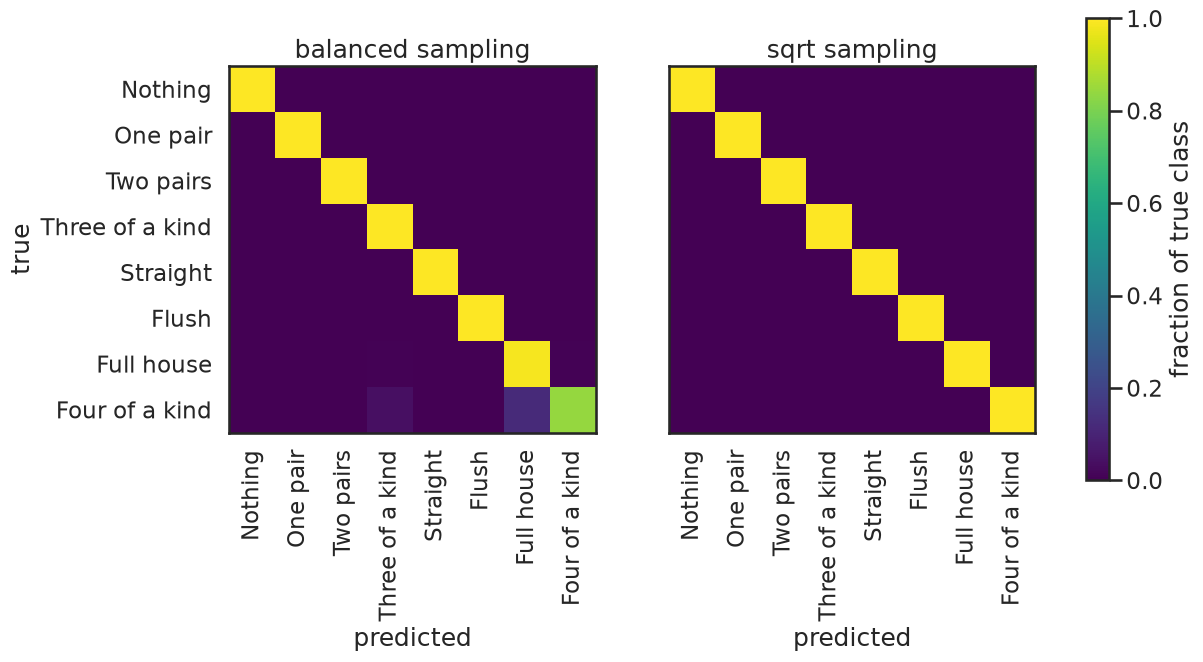

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, name in zip(axes, ['balanced', 'sqrt']):
    im = plot_confusion(pred[name], ax, name + ' sampling', ylabels=ax is axes[0])
fig.colorbar(im, ax=axes, label='fraction of true class')

Nothing was traded away. Flush **precision** is 100% for √-balanced and 98.9% for balanced, so the recovered flushes are not bought by relabelling thousands of *nothing* hands: the confusion matrix is very nearly diagonal, and *nothing* keeps 100% recall in both.

Two things need saying carefully before we draw a lesson from this table.

**1. Four of a kind has 25 validation hands.** Balanced scores 84% on it and √-balanced 100%: 21 hands against 25. One hand is four percentage points. Across three seeds the two regimes score anywhere between 84% and 100% on this class with no consistent ordering, so *we cannot rank them on it*, and neither should any reader of the table. The same arithmetic applies, less severely, to *full house* (145 hands) and *flush* (183).

What survives that noise is the big effect: **natural sampling gives near-zero flush recall, and every resampled regime recovers it completely.** That gap is 99 points, not 4.

**2. There was no accuracy to trade away.** The reason resampling costs nothing here is specific to this dataset: the label is a deterministic function of the input, so a classifier that is right about everything exists, and improving the rare classes does not have to come out of the common ones. On data where the classes genuinely overlap — a rare disease with symptoms that look like a common one, a rare species in a camera trap — a decision boundary really is a zero-sum allocation, and the trade-off is real. We meet a version of it below, when we reweight the loss instead of the sampler.

# "Cannot" or "has not yet"?

We have a model that scores 1.1% on flushes and a model that scores 100%, and the only difference between them is which hands the sampler handed them. It is tempting to conclude that natural sampling *cannot* learn flushes. That is a claim about a limit, and we should test it before believing it, because there is a much duller explanation available: at natural frequencies, flushes are 0.2% of the batch, so in 50,000 steps the model saw about 26,000 flushes — while the balanced model saw 1.3 million.

Maybe natural sampling is not blocked. Maybe it is just slow.

So train all three for **400,000 steps**, eight times the budget, and score them every 10,000 steps along the way. This takes about 25 minutes on a GPU, so the results are saved.

In [24]:
def train_curve(alpha, seed, total=400_000, every=10_000):
    # like train(), but scores the validation set every `every` steps
    w = train_counts.astype(float) ** alpha
    w = jnp.asarray(w / w.sum())
    opt = optax.adamw(1e-3, weight_decay=1e-4)
    params = init_params(jax.random.key(seed))
    state = opt.init(params)

    @jax.jit
    def step(params, state, key):
        kclass, khand = jax.random.split(key)
        idx = pool[jax.random.choice(kclass, NCLASSES, (BATCH,), p=w),
                   jax.random.randint(khand, (BATCH,), 0, L)]
        grads = jax.grad(loss)(params, train_suits_d[idx], train_ranks_d[idx], train_y_d[idx])
        updates, state = opt.update(grads, state, params)
        return optax.apply_updates(params, updates), state

    key = jax.random.key(seed + 1000)
    rows = []
    for i in range(1, total + 1):
        key, subkey = jax.random.split(key)
        params, state = step(params, state, subkey)
        if i % every == 0:
            y_pred = predict(params)
            recall = recall_score(val_y, y_pred, labels=REPORTED, average=None, zero_division=0)
            rows.append(dict(alpha=alpha, seed=seed, step=i, accuracy=accuracy_score(val_y, y_pred),
                             macro=recall.mean(), flush=recall[REPORTED.index(5)]))
    return rows

# About 25 minutes on a GPU for all six runs, so this is saved rather than rerun.
# curve = [row for alpha in [1.0, 0.5, 0.0] for seed in [0, 1] for row in train_curve(alpha, seed)]
# with open(DATA / 'poker_budget_curve.p', 'wb') as f:
#     pickle.dump(curve, f)

with open(DATA / 'poker_budget_curve.p', 'rb') as f:
    curve = pd.DataFrame(pickle.load(f))
curve.head()

,alpha,seed,step,accuracy,macro,flush
0,1.0,0,10000,0.813660,0.309749,0.000000
1,1.0,0,20000,0.987834,0.620176,0.000000
2,1.0,0,30000,0.997015,0.745965,0.000000
3,1.0,0,40000,0.997688,0.784356,0.000000
4,1.0,0,50000,0.997932,0.814870,0.098361


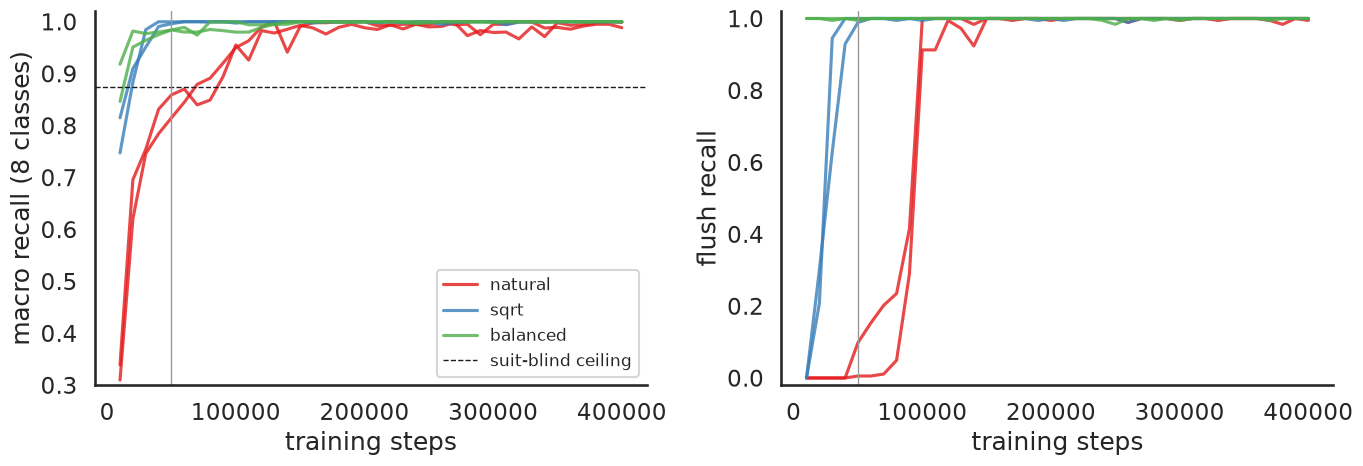

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for (alpha, name), color in zip([(1.0, 'natural'), (0.5, 'sqrt'), (0.0, 'balanced')], [red, blue, green]):
    sub = curve[curve.alpha == alpha]
    for metric, ax in zip(['macro', 'flush'], axes):
        for seed, g in sub.groupby('seed'):
            ax.plot(g.step, g[metric], color=color, alpha=0.8, label=name if seed == 0 else None)
axes[0].axhline(7 / 8, color='k', ls='--', lw=1, label='suit-blind ceiling')
axes[0].set(xlabel='training steps', ylabel='macro recall (8 classes)', ylim=(0.3, 1.02))
axes[1].set(xlabel='training steps', ylabel='flush recall', ylim=(-0.02, 1.02))
axes[0].axvline(STEPS, color='0.6', lw=1)
axes[1].axvline(STEPS, color='0.6', lw=1)
axes[0].legend(fontsize=12)
sns.despine()
fig.tight_layout()

The grey line is where we stopped. Everything to the right of it is what we did not see.

**Natural sampling gets there.** Flush recall is flat at zero through 40,000 steps, lifts off the floor right where we happened to stop measuring, and is at 100% by 100,000-150,000 steps. Macro recall crosses 95% at 100,000 and ends the run at 98.9% and 99.9% for the two seeds — the same place the resampled runs reached. Given four times the budget, the natural sampler learns the flush perfectly well.

The resampled runs simply get there sooner: √-balanced crosses 95% macro at 30,000 steps and balanced at 20,000, against natural's 100,000.

So the honest statement of what resampling did here is not *"it made an impossible class learnable"*:

> **Resampling bought sample efficiency.** It reached the same solution in three to five times fewer steps, by spending the gradient budget on the classes that were still wrong.

At 50,000 steps the two look like different kinds of model — one that "can't do flushes" and one that can. They are the same model at two points on the same curve. **A fixed training budget turns a difference in learning speed into what looks like a difference in capability**, and had we reported the 50,000-step table and stopped, we would have written the wrong sentence about our own model.

One detail in the table above is worth chasing rather than hiding, because a careful reader will spot it. The curve's own 50,000-step point reports **9.8%** flush recall for natural sampling at seed 0, while the checkpoint we have been scoring all notebook reports **1.1%** — same code, same seed, same step count. Look at where 50,000 falls on the right-hand panel: it is on the steep part, where a run's flush recall is anywhere between about 1% and 10%, and the GPU nondeterminism we flagged at the start is enough to move a run within that band. Which is the lesson once more: the number we would have reported depends on exactly where we stopped, and near a cliff it barely depends on us at all.

None of this is an argument for ignoring the sampler and training longer instead. Four times the compute is a real cost, and on a task with an irreducible error the extra steps may never arrive anywhere. It *is* an argument for distrusting "the model cannot learn the rare class" until you have seen what it does with more steps.

## A second probe of the same question

There is a cheaper test that asks something slightly different: not *"can training get there?"* but *"is the information already there?"*

Take the natural-sampling model at 50,000 steps — the one that scores 1.1% on flushes. **Freeze it**, throw away the readout layer, and fit a fresh linear classifier on the 150-dimensional hidden layer, using class-balanced draws. The features are fixed; only the decision boundary is allowed to move.

- If flush recall jumps, the features already encoded "all five suits agree". The network *had* the information, and the readout layer had no reason to use it.
- If it stays near zero, the network never built the feature, and no amount of re-weighting the boundary will invent it.

Both readings take the probe's number to mean something on its own. Hold on to that assumption; we are going to test it.

In [26]:
def train_probe(params, seed=0, steps=20_000):
    # a linear classifier on frozen features, trained on class-balanced draws
    w = jnp.full(NCLASSES, 1 / NCLASSES)
    opt = optax.adamw(1e-2, weight_decay=1e-4)
    head = dict(W=jnp.zeros((NHIDDEN, NCLASSES)), b=jnp.zeros(NCLASSES))
    state = opt.init(head)

    @jax.jit
    def step(head, state, key):
        kclass, khand = jax.random.split(key)
        idx = pool[jax.random.choice(kclass, NCLASSES, (BATCH,), p=w),
                   jax.random.randint(khand, (BATCH,), 0, L)]
        X = jax.lax.stop_gradient(features(params, train_suits_d[idx], train_ranks_d[idx]))
        y = train_y_d[idx]
        def head_loss(head):
            return optax.softmax_cross_entropy_with_integer_labels(X @ head['W'] + head['b'], y).mean()
        updates, state = opt.update(jax.grad(head_loss)(head), state, head)
        return optax.apply_updates(head, updates), state

    key = jax.random.key(seed + 2000)
    for _ in range(steps):
        key, subkey = jax.random.split(key)
        head, state = step(head, state, subkey)
    return jax.block_until_ready(head)

# head = train_probe(models['natural'])
# with open(DATA / 'poker_ffn_probe.p', 'wb') as f:
#     pickle.dump(jax.tree.map(np.asarray, head), f)

with open(DATA / 'poker_ffn_probe.p', 'rb') as f:
    head = jax.tree.map(jnp.asarray, pickle.load(f))

@jax.jit
def probe_batch(s, r):
    return (features(models['natural'], s, r) @ head['W'] + head['b']).argmax(axis=-1)

probe = np.concatenate([np.asarray(probe_batch(jnp.asarray(val_suits[i:i + 100_000]),
                                               jnp.asarray(val_ranks[i:i + 100_000])))
                        for i in range(0, len(val_suits), 100_000)])
report(probe)

                 precision    recall  f1-score   support

        Nothing      0.998     0.961     0.979     51472
       One pair      1.000     1.000     1.000     43276
      Two pairs      0.999     1.000     0.999      4813
Three of a kind      0.998     1.000     0.999      2176
       Straight      0.993     0.998     0.995       409
          Flush      0.050     0.579     0.092       183
     Full house      0.993     1.000     0.997       145
 Four of a kind      1.000     0.920     0.958        25

      micro avg      0.980     0.980     0.980    102499
      macro avg      0.879     0.932     0.878    102499
   weighted avg      0.997     0.980     0.988    102499

plain accuracy 0.9796   macro recall 0.9322


**Flush recall 58%, from a model whose own readout layer scored 1.1%** — on exactly the same features, which were not touched. The obvious reading is that the frozen network had built something responding to five matching suits, and its head had no incentive to act on it.

That reading is worth exactly one more experiment before we accept it. The probe is a linear classifier on 150 numbers; the question it really answers is *"can a linear map get flushes out of this representation?"*, and we have not checked how much of the answer is the representation and how much is the question being easy. So: **run the identical probe on a network that has never been trained at all.**

In [27]:
# random_head = train_probe(init_params(jax.random.key(0)))
# with open(DATA / 'poker_ffn_probe_random.p', 'wb') as f:
#     pickle.dump(jax.tree.map(np.asarray, random_head), f)

random_params = init_params(jax.random.key(0))
with open(DATA / 'poker_ffn_probe_random.p', 'rb') as f:
    random_head = jax.tree.map(jnp.asarray, pickle.load(f))

@jax.jit
def random_probe_batch(s, r):
    return (features(random_params, s, r) @ random_head['W'] + random_head['b']).argmax(axis=-1)

random_probe = np.concatenate([np.asarray(random_probe_batch(jnp.asarray(val_suits[i:i + 100_000]),
                                                             jnp.asarray(val_ranks[i:i + 100_000])))
                               for i in range(0, len(val_suits), 100_000)])
report(random_probe)

                 precision    recall  f1-score   support

        Nothing      0.574     0.198     0.294     51472
       One pair      0.415     0.045     0.081     43276
      Two pairs      0.051     0.038     0.044      4813
Three of a kind      0.033     0.059     0.042      2176
       Straight      0.009     0.477     0.018       409
          Flush      0.005     0.585     0.009       183
     Full house      0.002     0.200     0.004       145
 Four of a kind      0.001     0.360     0.001        25

      micro avg      0.126     0.125     0.125    102499
      macro avg      0.136     0.245     0.062    102499
   weighted avg      0.467     0.125     0.185    102499

plain accuracy 0.1248   macro recall 0.2452


In [28]:
comparison = pd.DataFrame({
    'trained features': {'flush recall': recall_score(val_y, probe, labels=[5], average='macro'),
                         'flush hits': confusion_matrix(val_y, probe, labels=range(NCLASSES))[5, 5],
                         'false flushes': confusion_matrix(val_y, probe, labels=range(NCLASSES))[0, 5],
                         'plain accuracy': accuracy_score(val_y, probe)},
    'random features': {'flush recall': recall_score(val_y, random_probe, labels=[5], average='macro'),
                        'flush hits': confusion_matrix(val_y, random_probe, labels=range(NCLASSES))[5, 5],
                        'false flushes': confusion_matrix(val_y, random_probe, labels=range(NCLASSES))[0, 5],
                        'plain accuracy': accuracy_score(val_y, random_probe)},
}).T
comparison.style.format({'flush recall': '{:.3f}', 'plain accuracy': '{:.4f}',
                         'flush hits': '{:.0f}', 'false flushes': '{:,.0f}'})

,flush recall,flush hits,false flushes,plain accuracy
trained features,0.579,106,"2,002",0.9796
random features,0.585,107,"12,484",0.1248


**A network that has never seen a single hand gives the probe 107 flushes out of 183. The trained network gave it 106.**

If recall is the number we are reading, the finding we were about to write down has just evaporated — and part of that is genuinely true. "All five suits agree" is a *shallow* function of the input: the suit embeddings are random vectors, they pass through one random linear map and a ReLU, and enough of that structure survives for a linear readout to lean on. A probe score confounds what a representation *contains* with how easy the target is to *extract*, and we had done nothing to separate the two.

But read the second column before concluding anything. To find its 106 flushes the trained probe flags **2,002** *nothing* hands; the random probe needs **12,484** to find 107. That is 3.9% of all *nothing* hands against 24% — a factor of six, at matched recall.

And that gap, unlike the recall, is a **controlled** comparison, because of where those hands live. Every *nothing* hand and every flush carries the same rank signature, $(1,1,1,1,1)$ and not a run — that was the entire point of the ceiling section. **Inside that group ranks carry no information at all.** Anything that separates flush from *nothing* there is suit information and nothing else, so a six-fold difference in false alarms cannot be put down to the trained network being better at reading ranks, or better at the task in general.

Matched recall is in any case a coincidence of where the two probes happen to have put their thresholds. So take the threshold out of it: rank every hand in the ambiguous group by the probe's flush-minus-*nothing* score, and ask how often a flush outranks a *nothing* hand.

In [29]:
ambiguous = np.array([rank_signature(r) == ((1, 1, 1, 1, 1), False) for r in val_ranks.tolist()])
ambiguous &= np.isin(val_y, [0, 5])      # Nothing or Flush: no rank signature can tell them apart
print('{:,} hands in the ambiguous group, of which {} flushes'.format(
    ambiguous.sum(), (val_y[ambiguous] == 5).sum()))

def flush_auc(params, classifier, chunk=100_000):
    # how often a flush outranks a Nothing hand, on the flush-minus-Nothing score
    s, r = val_suits[ambiguous], val_ranks[ambiguous]
    z = np.concatenate([np.asarray(features(params, jnp.asarray(s[i:i + chunk]), jnp.asarray(r[i:i + chunk]))
                                   @ classifier['W'] + classifier['b'])
                        for i in range(0, len(s), chunk)])
    return roc_auc_score(val_y[ambiguous] == 5, z[:, 5] - z[:, 0])

natural_head = {'W': models['natural']['W2'], 'b': models['natural']['b2']}
pd.Series({
    'probe on trained features': flush_auc(models['natural'], head),
    'probe on random features': flush_auc(random_params, random_head),
    "the natural model's own head": flush_auc(models['natural'], natural_head),
}).to_frame('flush vs Nothing, AUC').style.format('{:.3f}')

51,655 hands in the ambiguous group, of which 183 flushes


,"flush vs Nothing, AUC"
probe on trained features,0.947
probe on random features,0.764
the natural model's own head,0.920


**0.95 against 0.76.** Training *did* build suit discrimination, and substantially more of it than a random projection retains. The probe's recall column simply could not see it.

So the section ends up roughly where it started — the natural-sampling network has the suit signal and its head does not act on it — but for a reason it had to earn. What changed is that we now know which number was carrying the claim, and it was not the one in the headline.

And there is a third row in that table, which is the best one-line summary of this notebook's first half. Scored the same way, **the natural model's own readout head reaches 0.92**: it ranks flushes above *nothing* almost as well as the balanced probe does, while predicting flush for exactly 2 hands out of 183.

It is not that the model cannot tell a flush from nothing. **It can, and it declines to say so.** At natural frequencies, committing to *flush* is never worth the *nothing* hands it would cost, so the ranking is learned and the threshold never moves. The probe moves the threshold by fiat and buys recall at 5% precision. Changing the sampler does something better than either: it makes "all five suits agree" an exact test, which is why the resampled models get 100% recall *and* 100% precision rather than trading one against the other.

The experiment that answered "cannot or has not yet" was still the budget curve. At 50,000 steps under natural sampling the flush was never out of reach; it was **barely rewarded per step**, and 50,000 steps was not long enough for that to add up.

# Two alternatives that do not resample

Resampling is not the only way to tell a model that rare classes matter. Two standard alternatives are worth measuring here — with the warning attached up front that each is **one configuration at one budget**, and neither result is a verdict on the method.

## Class-weighted loss

Instead of changing *which* hands appear, keep natural sampling and change *how much each one counts*: multiply each hand's cross-entropy by $w_y \propto 1/n_y$. In expectation this is the same reweighting of the objective that balanced sampling performs.

In [30]:
prior = train_counts / train_counts.sum()
weights = jnp.asarray(NCLASSES * (1 / prior) / (1 / prior).sum())   # mean weight 1

def weighted_loss(params, s, r, y):
    ce = optax.softmax_cross_entropy_with_integer_labels(logits(params, s, r), y)
    return (ce * weights[y]).mean()

# train() again, natural sampling (alpha=1) but with weighted_loss in place of loss:
# params = train(1.0, loss_fn=weighted_loss)
# with open(DATA / 'poker_ffn_weighted.p', 'wb') as f:
#     pickle.dump(jax.tree.map(np.asarray, params), f)

weighted = predict(load('weighted'))
report(weighted)

                 precision    recall  f1-score   support

        Nothing      0.909     0.904     0.907     51472
       One pair      0.858     0.711     0.777     43276
      Two pairs      0.329     0.732     0.454      4813
Three of a kind      0.583     0.702     0.637      2176
       Straight      0.456     0.990     0.625       409
          Flush      0.330     0.967     0.492       183
     Full house      0.191     0.759     0.305       145
 Four of a kind      0.317     0.520     0.394        25

      micro avg      0.811     0.810     0.810    102499
      macro avg      0.497     0.786     0.574    102499
   weighted avg      0.849     0.810     0.822    102499

plain accuracy 0.8102   macro recall 0.7856


The same objective in expectation; not the same training run. Flush recall is recovered (96.7%), but plain accuracy collapses to 81% and macro recall to 78.6% — against balanced sampling's 99.99% and 97.8%. And it is not only the common classes that suffer: *one pair* falls to 71% recall and *two pairs* to 33% precision. This model is worse at nearly everything.

Be precise about what that does and does not establish. It is one weighting ($w \propto 1/n$, the textbook default), at one budget, on a dataset whose rarest weights belong to the two classes we have already declared unlearnable — the royal flush's 5 training hands carry a weight roughly 80,000 times a *nothing* hand's. It is not a demonstration that weighting the loss is worse than resampling in general.

What it does establish is narrower and still worth having: **in expectation the same objective, in practice not interchangeable.** The likely reason — likely, because we have not measured it here — is gradient *variance* rather than any difference in the expected objective. With weights spanning five orders of magnitude a single rare hand can dominate a batch's update, while balanced *sampling* reaches the same expected objective with every gradient the same size: it changes the frequency, not the magnitude. Exercise 5 measures that, and tries the standard fix of clipping the weights.

## Prior correction (logit adjustment)

The complementary idea ([Menon et al., 2021](https://arxiv.org/abs/2007.07314)): train on the balanced distribution, then correct the prediction back to the natural one at inference. A model trained on balanced data has implicitly learned that flushes are as common as *nothing*; adding $\log(\pi^{natural} / \pi^{train})$ to its logits undoes exactly that assumption, with no retraining.

In [31]:
adjustment = jnp.asarray(np.log(prior / (1 / NCLASSES)))   # log(natural prior / balanced prior)
print('correction spans {:.1f} nats, from {:+.2f} ({}) to {:+.2f} ({})'.format(
    adjustment.max() - adjustment.min(), adjustment.max(), CLASSES[int(adjustment.argmax())],
    adjustment.min(), CLASSES[int(adjustment.argmin())]))

@jax.jit
def adjusted_batch(params, s, r):
    return (logits(params, s, r) + adjustment).argmax(axis=-1)

adjusted = np.concatenate([np.asarray(adjusted_batch(models['balanced'], jnp.asarray(val_suits[i:i + 100_000]),
                                                     jnp.asarray(val_ranks[i:i + 100_000])))
                           for i in range(0, len(val_suits), 100_000)])

pd.DataFrame({'balanced': scores(pred['balanced']), 'balanced + logit adjustment': scores(adjusted)}).T.style.format('{:.5f}')

correction spans 11.3 nats, from +1.61 (Nothing) to -9.71 (Royal flush)


,accuracy,macro_recall
balanced,0.99991,0.97827
balanced + logit adjustment,0.99986,0.96670


A null result on accuracy, and a small loss on macro recall.

It is not that the correction is too small to matter: it spans **11.3 nats**, from $+1.61$ for *nothing* down to $-9.71$ for *royal flush*, with 5.5 nats of that separating *nothing* from *flush*. This is not a rounding error being added to the logits.

It does nothing useful because there is no **prior mismatch** left to repair. Logit adjustment fixes a model that was trained under one class distribution and deployed under another, by shifting the boundary back toward the common classes. Our balanced model is not systematically over-predicting rare classes: where it is right it is right by a wide margin, and its handful of errors are not of the kind a per-class constant addresses. So the shift buys no accuracy (99.991% → 99.986%) and costs 1.2 points of macro recall, by pushing a few rare-class hands over into the common classes — which is precisely what it is designed to do.

The conditions under which it earns its keep are the ones this dataset does not have: classes that genuinely overlap, so the boundary sits somewhere a prior can usefully move it. Keep it in the toolbox; do not expect it to improve a model that is already right.

# What the weights say, and what they do not

One last diagnostic, because it is commonly misused. The suit and rank embedding tables both start at RMS 0.02. Where do they end up under natural sampling?

In [32]:
rms = pd.DataFrame({name: {table: float(jnp.sqrt((params[table] ** 2).mean())) for table in ['suit', 'rank']}
                    for name, params in models.items()}).T
rms['rank / suit'] = rms['rank'] / rms['suit']
rms.style.format('{:.3f}')

,suit,rank,rank / suit
natural,0.377,1.154,3.057
balanced,0.655,1.372,2.094
sqrt,0.554,1.305,2.354


Under natural sampling the rank table ends up about three times the suit table, and the ratio shrinks under every resampling regime.

The tempting story is that weight decay switched the suit channel off — the objective did not reward it, so it was shrunk away. The numbers in the table refuse that story: the suit table is **nineteen times its initialisation**. It grew. Both tables grew; the ranks simply grew more. All the ratio records is that ranks were rewarded more than suits, which is the same thing the ceiling told us in a different unit, and it is not the mechanism behind the flush failure.

**Weight magnitude is evidence about what training rewarded. It is not evidence about what a model can or cannot do.** The probe above is the cautionary tale: its number meant something only after a control *and* the right column. This ratio has had neither, and there is no reading of it that would have told us what the AUC just did.

# Which number do you report?

Nothing in this session was about poker, and very little of it was about neural networks. The pattern is:

1. **Plain accuracy is an average over samples.** Under imbalance it is a report on the common classes. Always print the majority-class baseline next to it — if your model is not far above it, the accuracy is telling you about the class frequencies, not the model.
2. **Macro recall gives every class one vote**, which is the right summary when the rare classes are the ones you care about. It is also fragile in exactly the place it is useful: a class with 25 validation examples moves 4 points per hand. Report supports, and say what the seed-to-seed spread is.
3. **Score only the classes you have the data to score**, say so explicitly, and pass `labels=` so the average cannot silently change underneath you.
4. **Recall is half a statement.** Always show precision, or a confusion matrix, alongside it. "Balanced sampling fixed the flush" and "balanced sampling labels a thousand junk hands as flushes" are both compatible with 100% recall.
5. **Work out what the task requires before diagnosing your model.** The suit-blind ceiling took three lines and no GPU, and it changed the question from *"why is the model bad at flushes?"* to *"why would any model trained this way bother?"*
6. **Before concluding the model cannot, check whether it merely has not yet.** A fixed budget disguises a difference in learning speed as a difference in capability.
7. **A diagnostic needs a control, and the right column.** Our probe's 58% flush recall looked like a finding, and an untrained network matched it exactly — but at six times the false-alarm rate, inside the one group of hands where only the suits can decide. Recall was uninformative; the controlled, threshold-free comparison (AUC 0.95 against 0.76) carried the evidence. Ask what your number reads on a baseline, and check that you are reading a column that can discriminate at all.

And the one to carry furthest: **which metric you report is a statement about who is harmed by an error.** Plain accuracy is the right summary when every hand costs the same. Macro recall is the right summary when the rare class is the expensive one — the fraud, the tumour, the endangered animal. The model does not know which situation it is in. You do, and the sampler is one of the places you get to say so.

# Exercises

1. **Sweep the exponent.** We used $\alpha \in \{0, 0.5, 1\}$. Train with $\alpha \in \{0, 0.25, 0.5, 0.75, 1\}$ and plot plain accuracy and macro recall against $\alpha$, with **at least three seeds per value** and the seed spread drawn on the plot. Is the curve a smooth slope, or something else? Compare the spread between seeds at one $\alpha$ to the differences between neighbouring $\alpha$ — how carefully does this hyperparameter actually need to be chosen, and would you have known that from one seed?

2. **The test set.** Everything above was measured on the validation split, and we chose $\alpha$, the budget and the architecture while looking at it. Score the best model on `perm[ntrain + nval:]`, which nothing in this notebook has touched. How much does each number move, and which ones move most?

3. **Make the ceiling bind.** Delete the suits from the input entirely (feed a constant suit index) and retrain with √-balanced sampling. Does the model reach the 87.5% suit-blind ceiling? This is the control for the whole middle of the notebook: it separates "the sampler was the problem" from "the suits were the problem".

4. **A budget you cannot escape.** Retrain the natural regime for 400,000 steps but with a model one-tenth the size (`NHIDDEN = 15`). Does the flush still arrive, and when? What does this say about whether the budget curve above is a property of the sampler or of the model?

5. **Where did the weighted loss go wrong?** The class-weighted run above collapsed, and we attributed it to gradient variance without measuring it. Measure it: draw 200 batches under natural sampling, record the norm of the weighted-loss gradient for each, and compare its mean and standard deviation to the same statistic under balanced sampling with the unweighted loss. Then try the standard repair — clip the weights at, say, the 95th percentile, or drop the two unlearnable classes from the weighting — and retrain. How much of the collapse comes back?

6. **A harder version of the same lesson.** Add label noise: flip 5% of the training labels to a uniformly random class, then repeat the natural / balanced / √-balanced comparison. A perfect classifier no longer exists. Does resampling still improve both metrics at once, or does the trade-off the literature warns about finally appear?

# References

- [UCI Poker Hand dataset](https://archive.ics.uci.edu/dataset/158/poker+hand) (Cattral, Oppacher & Deugo, 2007)
- ProbML - [Probabilistic Machine Learning: An Introduction](https://probml.github.io/pml-book/book1.html) by Kevin P. Murphy, ch. 5.1 - decision theory, and why a choice of metric is a choice about costs
- [Menon, Jayasumana, Rawat, Jain, Veit & Kumar, *Long-tail learning via logit adjustment*, ICLR 2021](https://arxiv.org/abs/2007.07314)
- [Buda, Maki & Mazurowski, *A systematic study of the class imbalance problem in convolutional neural networks*, Neural Networks 2018](https://arxiv.org/abs/1710.05381) - oversampling, undersampling and thresholding, compared across datasets
- [Mahajan et al., *Exploring the limits of weakly supervised pretraining*, ECCV 2018](https://arxiv.org/abs/1805.00932) - §4.2 is where the $n^{1/2}$ sampling exponent comes from, at a rather larger scale
- [Van Horn & Perona, *The devil is in the tails*, 2017](https://arxiv.org/abs/1709.01450) - what long-tailed class distributions look like in the wild

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)